<!-- codex-architecture-notes -->
## Architectural Notes

**Purpose:** Explores the inactive outlier-removal branch for controlled modeling experiments.

**Notebook Shape:** 16 cells (15 code, 1 markdown).

**Inputs / Data Sources:**
df_crg_add_acd.parquet

**Outputs / Side Effects:**
- `without_outliers.parquet`

**Logic Flow:**
1. Load a feature dataset from parquet/csv/excel.
2. Inspect distributions and outlier candidates.
3. Filter or cap suspicious records.
4. Write the outlier-handled parquet output.

**Maintainability Notes:** Outlier thresholds are notebook-local; promote them into `src.feature_engineering` if they become part of the official model contract.


# Explore Outlier Removal

Fill `path` with your dataframe file path, then run the notebook. The notebook is saved with no executed cells and no outputs.

This notebook prepares the dataframe before temporal split. It does not train a model, does not calculate course difficulty, and does not use a scaler for outliers.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
from src.paths import FEATURES_DIR, FINAL_DIR, assert_data_root
from src.io_utils import save_parquet


In [2]:
# Put your file path here.
path = FEATURES_DIR / "selected_model_population.parquet"

# Main rules.
MAX_ALLOWED_SEMESTER_CREDITS = 25
MAX_ALLOWED_SEMESTER_COURSES = 8
FAIL_CREDITS_CAP = 120
HIGH_COURSE_CREDITS_VALUE = 24
MIN_VALID_PREV_GPA_POINTS = 0

# Plot sample size. This keeps plots readable if the data is very large.
PLOT_SAMPLE_SIZE = 10_000


In [3]:
# Load the dataframe.
file_path = Path(path)
assert_data_root(file_path)

if not path:
    raise ValueError('Fill the path variable before running this notebook.')

if file_path.suffix.lower() in ['.parquet', '.pq']:
    df_feature = pd.read_parquet(file_path)
elif file_path.suffix.lower() == '.csv':
    df_feature = pd.read_csv(file_path)
elif file_path.suffix.lower() in ['.xlsx', '.xls']:
    df_feature = pd.read_excel(file_path)
elif file_path.suffix.lower() in ['.pkl', '.pickle']:
    df_feature = pd.read_pickle(file_path)
else:
    raise ValueError(f'Unsupported file type: {file_path.suffix}')

df_feature.head()


,student_course_id,student_id,course_id,part_id,degree_id,faculty_id,grade_id,final_mark,course_credits,attempt_number,student_status_id,prev_gpa_points,gpa_points,start_agpa_points,start_total_in_courses,start_total_in_credits,semester_reg_credits,semester_reg_courses,semester_pass_credits,total_pass_credits,total_fail_credits,reg_total_semesters,start_level_name_pl,start_part_id,requirement_type_id,degree_requirement_credits_count,diploma_gpa,diploma_type_id
0,939272.111,10000.111,1016.111,20152,3.111,5.111,677.111,82,2.0,1,155348.111,2.41,2.36,2.41,6.0,17.0,18.0,6.0,18.0,17.0,0.0,2.0,First Year,20151,2,6,74.71,15
1,953865.111,10000.111,1017.111,20153,3.111,5.111,680.111,67,2.0,1,155349.111,2.36,2.25,2.39,12.0,35.0,9.0,3.0,9.0,35.0,0.0,3.0,Second Year,20151,2,6,74.71,15
2,1076397.111,10000.111,1019.111,20171,3.111,5.111,981.111,66,2.0,1,240678.111,2.17,1.76,2.28,27.0,80.0,17.0,6.0,17.0,80.0,0.0,6.0,Third year,20151,2,6,74.71,15
3,925010.111,10000.111,431.111,20152,3.111,5.111,677.111,83,3.0,1,155348.111,2.41,2.36,2.41,6.0,17.0,18.0,6.0,18.0,17.0,0.0,2.0,First Year,20151,3,65,74.71,15
4,901340.111,10000.111,432.111,20151,3.111,5.111,681.111,61,4.0,1,155347.111,<NA>,2.41,0.0,0.0,0.0,17.0,6.0,17.0,0.0,0.0,1.0,First Year,20151,3,65,74.71,15


In [4]:
# Make a working copy.
df = df_feature.copy()
original_columns = set(df.columns)
original_row_count = len(df)

# These columns must exist.
required_columns = [
    'student_id',
    'course_id',
    'degree_id',
    'part_id',
    'final_mark',
    'course_credits',
    'semester_reg_credits',
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

# These columns are useful, but if they do not exist we create simple default values.
optional_defaults = {
    'attempt_number': 1,
    'gpa_points': np.nan,
    'semester_pass_credits': np.nan,
    'prev_gpa_points': np.nan,
    'start_agpa_points': np.nan,
    'start_total_in_courses': 0,
    'start_total_in_credits': 0,
    'semester_reg_courses': np.nan,
    'total_pass_credits': np.nan,
    'total_fail_credits': 0,
    'reg_total_semesters': 0,
    'start_level_name_pl': pd.NA,
    'start_part_id': pd.NA,
    'requirement_type_id': pd.NA,
    'degree_requirement_credits_count': np.nan,
}

for col, value in optional_defaults.items():
    if col not in df.columns:
        df[col] = value

# Convert numeric columns to numbers.
numeric_columns = [
    'final_mark',
    'course_credits',
    'attempt_number',
    'gpa_points',
    'semester_reg_credits',
    'semester_pass_credits',
    'prev_gpa_points',
    'start_agpa_points',
    'start_total_in_courses',
    'start_total_in_credits',
    'semester_reg_courses',
    'total_pass_credits',
    'total_fail_credits',
    'reg_total_semesters',
    'requirement_type_id',
    'degree_requirement_credits_count',
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Original rows:', original_row_count)
print('Columns:', len(df.columns))
display(df.head())
display(df.isna().sum().sort_values(ascending=False).to_frame('null_count'))


Original rows: 761346
Columns: 28


,student_course_id,student_id,course_id,part_id,degree_id,faculty_id,grade_id,final_mark,course_credits,attempt_number,student_status_id,prev_gpa_points,gpa_points,start_agpa_points,start_total_in_courses,start_total_in_credits,semester_reg_credits,semester_reg_courses,semester_pass_credits,total_pass_credits,total_fail_credits,reg_total_semesters,start_level_name_pl,start_part_id,requirement_type_id,degree_requirement_credits_count,diploma_gpa,diploma_type_id
0,939272.111,10000.111,1016.111,20152,3.111,5.111,677.111,82,2.0,1,155348.111,2.41,2.36,2.41,6.0,17.0,18.0,6.0,18.0,17.0,0.0,2.0,First Year,20151,2,6,74.71,15
1,953865.111,10000.111,1017.111,20153,3.111,5.111,680.111,67,2.0,1,155349.111,2.36,2.25,2.39,12.0,35.0,9.0,3.0,9.0,35.0,0.0,3.0,Second Year,20151,2,6,74.71,15
2,1076397.111,10000.111,1019.111,20171,3.111,5.111,981.111,66,2.0,1,240678.111,2.17,1.76,2.28,27.0,80.0,17.0,6.0,17.0,80.0,0.0,6.0,Third year,20151,2,6,74.71,15
3,925010.111,10000.111,431.111,20152,3.111,5.111,677.111,83,3.0,1,155348.111,2.41,2.36,2.41,6.0,17.0,18.0,6.0,18.0,17.0,0.0,2.0,First Year,20151,3,65,74.71,15
4,901340.111,10000.111,432.111,20151,3.111,5.111,681.111,61,4.0,1,155347.111,<NA>,2.41,0.0,0.0,0.0,17.0,6.0,17.0,0.0,0.0,1.0,First Year,20151,3,65,74.71,15


,null_count
prev_gpa_points,91616
reg_total_semesters,3183
requirement_type_id,1720
degree_requirement_credits_count,1720
diploma_gpa,48
diploma_type_id,48
grade_id,0
degree_id,0
part_id,0
student_course_id,0


In [5]:
# Look at the start level values before mapping them.
start_level_values = (
    df['start_level_name_pl']
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .sort_values()
)

display(start_level_values.to_frame('start_level_name_pl'))

# Broad before-cleaning plots were removed. The only plots kept in this notebook
# focus on the interruption and previous-GPA cleaning changes below.


,start_level_name_pl
11,Fifth year
0,First Year
8,Fourth Year
1,Second Year
207,Sixth Year
2,Third year


In [6]:
# 1. Create policy and audit flags on the full dataframe.
# course_credits = 24 is valid. Keep it and expose it as a feature/audit flag.
df['is_high_credit_course'] = (df['course_credits'] == HIGH_COURSE_CREDITS_VALUE).astype(int)

df['over_policy_semester_credits'] = df['semester_reg_credits'] > MAX_ALLOWED_SEMESTER_CREDITS

if 'semester_reg_courses' in df.columns:
    df['over_policy_semester_courses'] = df['semester_reg_courses'] > MAX_ALLOWED_SEMESTER_COURSES
else:
    print('WARNING: semester_reg_courses is missing; course-count overload check was skipped.')
    df['over_policy_semester_courses'] = False

df['exclude_over_policy_semester'] = df['over_policy_semester_credits'] | df['over_policy_semester_courses']

df['total_fail_credits'] = df['total_fail_credits'].fillna(0)
df['is_extreme_fail_history'] = (df['total_fail_credits'] > FAIL_CREDITS_CAP).astype(int)
df['total_fail_credits_capped'] = df['total_fail_credits'].clip(upper=FAIL_CREDITS_CAP)

# Freeze the full audit dataframe before Model A feature engineering.
df_model_audit = df.copy()
df_excluded_over_policy = df_model_audit[df_model_audit['exclude_over_policy_semester']].copy()
df_primary = df_model_audit[~df_model_audit['exclude_over_policy_semester']].copy()

print('Full audit rows:', len(df_model_audit))
print('Excluded over-policy rows:', len(df_excluded_over_policy))
print('Primary Model A rows:', len(df_primary))

# 2. Build student-semester features from df_primary only.
semester_key = ['student_id', 'degree_id', 'part_id']
student_degree_key = ['student_id', 'degree_id']
semester_value_columns = [
    'gpa_points',
    'semester_reg_credits',
    'semester_pass_credits',
    'start_total_in_courses',
    'start_total_in_credits',
    'start_agpa_points',
    'prev_gpa_points',
]
semester_value_columns = [col for col in semester_value_columns if col in df_primary.columns]

# Audit duplicated course rows before aggregation. These columns should be repeated
# within each student-degree-semester, so conflicting values are warnings.
conflict_frames = []
for col in semester_value_columns:
    col_conflicts = (
        df_primary.groupby(semester_key, dropna=False)[col]
        .nunique(dropna=False)
        .reset_index(name='unique_value_count')
    )
    col_conflicts = col_conflicts[col_conflicts['unique_value_count'] > 1].copy()
    if not col_conflicts.empty:
        col_conflicts.insert(0, 'column', col)
        conflict_frames.append(col_conflicts)

if conflict_frames:
    semester_conflict_report = pd.concat(conflict_frames, ignore_index=True)
    print('WARNING: semester-level columns have conflicting values within some student-degree-semesters. Aggregation will use max.')
    display(semester_conflict_report.head(25))
else:
    semester_conflict_report = pd.DataFrame(columns=['column'] + semester_key + ['unique_value_count'])
    print('No semester-level conflicts detected before aggregation.')

# Use max consistently because these semester attributes should be repeated per course row.
semester_df = (
    df_primary.groupby(semester_key, dropna=False, as_index=False)
    .agg({col: 'max' for col in semester_value_columns})
)

semester_df['_student_sort'] = semester_df['student_id'].astype('string')
semester_df['_degree_sort'] = semester_df['degree_id'].astype('string')
semester_df['_part_sort_numeric'] = pd.to_numeric(semester_df['part_id'], errors='coerce')
semester_df['_part_sort_text'] = semester_df['part_id'].astype('string')
semester_df = (
    semester_df
    .sort_values(
        ['_student_sort', '_degree_sort', '_part_sort_numeric', '_part_sort_text'],
        kind='mergesort',
        na_position='last',
    )
    .drop(columns=['_student_sort', '_degree_sort', '_part_sort_numeric', '_part_sort_text'])
    .reset_index(drop=True)
)

semester_df['is_interruption_semester'] = (
    semester_df['semester_reg_credits'].fillna(0).gt(0)
    & semester_df['semester_pass_credits'].fillna(0).eq(0)
    & semester_df['gpa_points'].eq(0).fillna(False)
).astype(int)

semester_group = semester_df.groupby(student_degree_key, dropna=False, sort=False)
semester_df['prev_semester_was_interruption'] = (
    semester_group['is_interruption_semester']
    .shift(1)
    .fillna(0)
    .astype(int)
)
semester_df['prior_interruption_count'] = (
    semester_group['is_interruption_semester'].cumsum() - semester_df['is_interruption_semester']
).astype(int)


def _prior_consecutive_interruptions(flags):
    counts = []
    current_run = 0
    for flag in flags.fillna(0).astype(int):
        counts.append(current_run)
        current_run = current_run + 1 if flag == 1 else 0
    return pd.Series(counts, index=flags.index)


semester_df['consecutive_interruption_count'] = (
    semester_group['is_interruption_semester']
    .transform(_prior_consecutive_interruptions)
    .astype(int)
)

semester_df['no_previous_progress'] = (
    semester_df['start_total_in_courses'].fillna(0).eq(0)
    & semester_df['start_total_in_credits'].fillna(0).eq(0)
).astype(int)
semester_df['is_first_active_semester'] = semester_df['no_previous_progress']

# Ignore interruption semesters, then shift the filled GPA to get the nearest valid previous GPA.
semester_df['semester_gpa_for_history'] = semester_df['gpa_points'].where(
    semester_df['is_interruption_semester'].eq(0)
)
semester_group = semester_df.groupby(student_degree_key, dropna=False, sort=False)
semester_df['_filled_valid_gpa'] = semester_group['semester_gpa_for_history'].ffill()
semester_group = semester_df.groupby(student_degree_key, dropna=False, sort=False)
semester_df['last_valid_gpa_before_current_semester'] = semester_group['_filled_valid_gpa'].shift(1)
semester_df = semester_df.drop(columns=['_filled_valid_gpa'])

# 3. Merge semester-level features back to df_primary with safe string keys.
merge_key_columns = ['_student_merge_key', '_degree_merge_key', '_part_merge_key']
source_key_columns = ['student_id', 'degree_id', 'part_id']
for merge_col, source_col in zip(merge_key_columns, source_key_columns):
    df_primary[merge_col] = df_primary[source_col].astype('string').fillna('__MISSING__')
    semester_df[merge_col] = semester_df[source_col].astype('string').fillna('__MISSING__')

semester_feature_columns = [
    'is_interruption_semester',
    'prev_semester_was_interruption',
    'prior_interruption_count',
    'consecutive_interruption_count',
    'no_previous_progress',
    'is_first_active_semester',
    'last_valid_gpa_before_current_semester',
]
semester_feature_columns = [col for col in semester_feature_columns if col in semester_df.columns]
semester_feature_df = semester_df[merge_key_columns + semester_feature_columns].drop_duplicates(merge_key_columns).copy()

merge_preview = df_primary[merge_key_columns].merge(
    semester_feature_df[merge_key_columns],
    on=merge_key_columns,
    how='left',
    indicator=True,
)
semester_feature_merge_counts = merge_preview['_merge'].value_counts()
print('Semester feature merge check:')
display(semester_feature_merge_counts.to_frame('row_count'))

left_only_keys = merge_preview.loc[merge_preview['_merge'].eq('left_only'), merge_key_columns].drop_duplicates()
if not left_only_keys.empty:
    print('WARNING: Some df_primary rows did not match semester_df. Example keys:')
    display(left_only_keys.head(25))

df_primary = df_primary.merge(
    semester_feature_df,
    on=merge_key_columns,
    how='left',
    validate='many_to_one',
    indicator='_semester_feature_merge',
)
print('Actual semester feature merge result:')
display(df_primary['_semester_feature_merge'].value_counts().to_frame('row_count'))

semester_last_valid_non_null = int(semester_df['last_valid_gpa_before_current_semester'].notna().sum())
primary_last_valid_non_null = int(df_primary['last_valid_gpa_before_current_semester'].notna().sum())
print('Non-null last_valid_gpa_before_current_semester in semester_df:', semester_last_valid_non_null)
print('Non-null last_valid_gpa_before_current_semester in df_primary:', primary_last_valid_non_null)

if semester_last_valid_non_null > 0 and primary_last_valid_non_null == 0:
    raise ValueError('last_valid_gpa_before_current_semester merge failed: semester_df has values but df_primary has none.')

for col in [c for c in semester_feature_columns if c != 'last_valid_gpa_before_current_semester']:
    df_primary[col] = df_primary[col].fillna(0).astype(int)

df_primary = df_primary.drop(columns=merge_key_columns + ['_semester_feature_merge'], errors='ignore')

# 4. Clean prev_gpa_points on df_primary only. Keep raw prev_gpa_points unchanged.
# Use only positive GPA values; zero is treated as an old-system/system placeholder.
# Source order: raw prev_gpa_points -> nearest previous valid GPA -> start_agpa_points.
# 4. Clean prev_gpa_points on df_primary only. Keep raw prev_gpa_points unchanged.
# Use only positive GPA values; zero is treated as an old-system/system placeholder.
# Source order:
# raw prev_gpa_points > 0
# -> last_valid_gpa_before_current_semester > 0
# -> start_agpa_points > 0
# -> 0 final fallback

MIN_VALID_PREV_GPA_POINTS = 0

raw_prev_gpa = pd.to_numeric(df_primary["prev_gpa_points"], errors="coerce")
last_valid_prev_gpa = pd.to_numeric(df_primary["last_valid_gpa_before_current_semester"], errors="coerce")
start_agpa_points = pd.to_numeric(df_primary["start_agpa_points"], errors="coerce")

df_primary["prev_gpa_points_missing"] = raw_prev_gpa.isna().astype(int)
df_primary["prev_gpa_points_zero"] = raw_prev_gpa.eq(0).fillna(False).astype(int)

df_primary["prev_gpa_invalid_zero_case"] = (
    raw_prev_gpa.eq(0).fillna(False)
    & df_primary["is_first_active_semester"].ne(1)
).astype(int)

df_primary["prev_gpa_points_clean"] = np.nan
df_primary["prev_gpa_fill_source"] = pd.Series(pd.NA, index=df_primary.index, dtype="string")

prev_gpa_sources = [
    ("raw_prev_gpa", raw_prev_gpa),
    ("last_valid_gpa_before_current_semester", last_valid_prev_gpa),
    ("start_agpa_points", start_agpa_points),
]

for source_name, source_values in prev_gpa_sources:
    needs_value = df_primary["prev_gpa_points_clean"].isna()
    source_has_value = source_values.gt(MIN_VALID_PREV_GPA_POINTS).fillna(False)

    use_source = needs_value & source_has_value

    df_primary.loc[use_source, "prev_gpa_points_clean"] = source_values.loc[use_source]
    df_primary.loc[use_source, "prev_gpa_fill_source"] = source_name

# Final fallback: if still NaN, set to 0
needs_zero_fallback = df_primary["prev_gpa_points_clean"].isna()

df_primary.loc[needs_zero_fallback, "prev_gpa_points_clean"] = 0
df_primary.loc[needs_zero_fallback, "prev_gpa_fill_source"] = "zero_fallback"

# Audit flags
df_primary["prev_gpa_replaced_due_to_invalid_zero"] = (
    df_primary["prev_gpa_invalid_zero_case"].eq(1)
    & df_primary["prev_gpa_fill_source"].ne("raw_prev_gpa")
).astype(int)

# Since support confirmed prev_gpa_points == 0 is an old/system case,
# do not treat zero as real academic performance.
df_primary["prev_gpa_actual_zero_performance"] = 0

# Final validation
remaining_nan_count = df_primary["prev_gpa_points_clean"].isna().sum()
print("Remaining NaN in prev_gpa_points_clean:", remaining_nan_count)

assert remaining_nan_count == 0, "prev_gpa_points_clean still contains NaN values."

print("prev_gpa_fill_source distribution:")
display(df_primary["prev_gpa_fill_source"].value_counts(dropna=False).to_frame("row_count"))

print("prev_gpa_points_clean summary:")
display(df_primary["prev_gpa_points_clean"].describe())

display(
    df_primary.loc[
        df_primary["prev_gpa_fill_source"].eq("zero_fallback"),
        [
            "student_id",
            "degree_id",
            "part_id",
            "prev_gpa_points",
            "last_valid_gpa_before_current_semester",
            "start_agpa_points",
            "prev_gpa_points_clean",
            "prev_gpa_fill_source",
            "is_first_active_semester",
        ]
    ].head(25)
)
# 5. Split part_id and start_part_id into year and semester columns. Keep raw part_id.
part_text = df_primary['part_id'].astype('string').str.extract(r'(\d{4})\D*(\d+)')
df_primary['part_year'] = pd.to_numeric(part_text[0], errors='coerce')
df_primary['part_semester'] = pd.to_numeric(part_text[1], errors='coerce')

start_part_text = df_primary['start_part_id'].astype('string').str.extract(r'(\d{4})\D*(\d+)')
df_primary['start_year'] = pd.to_numeric(start_part_text[0], errors='coerce')
df_primary['start_semester'] = pd.to_numeric(start_part_text[1], errors='coerce')

# 6. Convert start_level_name_pl to academic order. Missing or unknown levels become 0.
# Values are lower case because start_level_clean is stripped and lowercased below.
level_order = {
    "first year": 1,
    "second year": 2,
    "third year": 3,
    "fourth year": 4,
    "fifth year": 5,
    "sixth year": 6,
}

start_level_clean = (
    df_primary["start_level_name_pl"]
    .astype("string")
    .str.strip()
    .str.lower()
)

start_level_clean = start_level_clean.mask(start_level_clean.fillna("").eq(""))

df_primary["start_level_missing"] = start_level_clean.isna().astype(int)

df_primary["start_level_ord"] = (
    start_level_clean
    .map(level_order)
    .fillna(0)
    .astype(int)
)

# 7. Requirement features.
df_primary['requirement_type_missing'] = df_primary['requirement_type_id'].isna().astype(int)
df_primary['requirement_type_id'] = df_primary['requirement_type_id'].fillna(-1).astype('Int64')

df_primary['degree_requirement_credits_count_missing'] = df_primary['degree_requirement_credits_count'].isna().astype(int)
df_primary['degree_requirement_credits_count'] = df_primary['degree_requirement_credits_count'].fillna(0)

df_primary['course_share_of_requirement'] = 0.0
valid_requirement = df_primary['degree_requirement_credits_count'] > 0
df_primary.loc[valid_requirement, 'course_share_of_requirement'] = (
    df_primary.loc[valid_requirement, 'course_credits'] / df_primary.loc[valid_requirement, 'degree_requirement_credits_count']
)

df_primary['requirement_size_bucket'] = pd.cut(
    df_primary['degree_requirement_credits_count'],
    bins=[-0.01, 0, 12, 24, 60, np.inf],
    labels=['none_or_unknown', 'small', 'medium', 'large', 'very_large'],
).astype('string').fillna('unknown')

# 8. Keep this key for later encoding or course statistics. Do not calculate course difficulty here.
df_primary['degree_course_key'] = df_primary['degree_id'].astype('string') + '__' + df_primary['course_id'].astype('string')

# 9. Row-wise failure ratio.
fail_credit_denominator = df_primary['start_total_in_credits'].fillna(0) + df_primary['total_fail_credits_capped'].fillna(0)
df_primary['fail_credit_ratio_capped'] = 0.0
valid_fail_ratio = fail_credit_denominator > 0
df_primary.loc[valid_fail_ratio, 'fail_credit_ratio_capped'] = (
    df_primary.loc[valid_fail_ratio, 'total_fail_credits_capped'] / fail_credit_denominator.loc[valid_fail_ratio]
)

display(pd.Series(level_order, name='start_level_ord').rename_axis('start_level_name_pl').reset_index())
display(df_primary.head())


Full audit rows: 761346
Excluded over-policy rows: 33494
Primary Model A rows: 727852
No semester-level conflicts detected before aggregation.
Semester feature merge check:


,row_count
_merge,
both,727852
left_only,0
right_only,0


Actual semester feature merge result:


,row_count
_semester_feature_merge,
both,727852
left_only,0
right_only,0


Non-null last_valid_gpa_before_current_semester in semester_df: 141412
Non-null last_valid_gpa_before_current_semester in df_primary: 629527
Remaining NaN in prev_gpa_points_clean: 0
prev_gpa_fill_source distribution:


...

prev_gpa_points_clean summary:


count    727852.000000
mean          1.900681
std           1.024438
min           0.000000
25%           1.250000
50%           2.140000
75%           2.670000
max           4.000000
Name: prev_gpa_points_clean, dtype: float64

,student_id,degree_id,part_id,prev_gpa_points,last_valid_gpa_before_current_semester,start_agpa_points,prev_gpa_points_clean,prev_gpa_fill_source,is_first_active_semester
4,10000.111,3.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1
16,10000.111,3.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1
26,10000.111,3.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1
56,10000.111,3.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1
57,10000.111,3.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1
59,10000.111,3.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1
86,10001.111,13.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1
88,10001.111,13.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1
89,10001.111,13.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1
90,10001.111,13.111,20151,<NA>,<NA>,0.0,0.0,zero_fallback,1


,start_level_name_pl,start_level_ord
0,first year,1
1,second year,2
2,third year,3
3,fourth year,4
4,fifth year,5
5,sixth year,6


,student_course_id,student_id,course_id,part_id,degree_id,faculty_id,grade_id,final_mark,course_credits,attempt_number,student_status_id,prev_gpa_points,gpa_points,start_agpa_points,start_total_in_courses,start_total_in_credits,semester_reg_credits,semester_reg_courses,semester_pass_credits,total_pass_credits,total_fail_credits,reg_total_semesters,start_level_name_pl,start_part_id,requirement_type_id,degree_requirement_credits_count,diploma_gpa,diploma_type_id,is_high_credit_course,over_policy_semester_credits,over_policy_semester_courses,exclude_over_policy_semester,is_extreme_fail_history,total_fail_credits_capped,is_interruption_semester,prev_semester_was_interruption,prior_interruption_count,consecutive_interruption_count,no_previous_progress,is_first_active_semester,last_valid_gpa_before_current_semester,prev_gpa_points_missing,prev_gpa_points_zero,prev_gpa_invalid_zero_case,prev_gpa_points_clean,prev_gpa_fill_source,prev_gpa_replaced_due_to_invalid_zero,prev_gpa_actual_zero_performance,part_year,part_semester,start_year,start_semester,start_level_missing,start_level_ord,requirement_type_missing,degree_requirement_credits_count_missing,course_share_of_requirement,requirement_size_bucket,degree_course_key,fail_credit_ratio_capped
0,939272.111,10000.111,1016.111,20152,3.111,5.111,677.111,82,2.0,1,155348.111,2.41,2.36,2.41,6.0,17.0,18.0,6.0,18.0,17.0,0.0,2.0,First Year,20151,2,6,74.71,15,0,False,False,False,0,0.0,0,0,0,0,0,0,2.41,0,0,0,2.41,raw_prev_gpa,0,0,2015,2,2015,1,0,1,0,0,0.333333,small,3.111__1016.111,0.0
1,953865.111,10000.111,1017.111,20153,3.111,5.111,680.111,67,2.0,1,155349.111,2.36,2.25,2.39,12.0,35.0,9.0,3.0,9.0,35.0,0.0,3.0,Second Year,20151,2,6,74.71,15,0,False,False,False,0,0.0,0,0,0,0,0,0,2.36,0,0,0,2.36,raw_prev_gpa,0,0,2015,3,2015,1,0,2,0,0,0.333333,small,3.111__1017.111,0.0
2,1076397.111,10000.111,1019.111,20171,3.111,5.111,981.111,66,2.0,1,240678.111,2.17,1.76,2.28,27.0,80.0,17.0,6.0,17.0,80.0,0.0,6.0,Third year,20151,2,6,74.71,15,0,False,False,False,0,0.0,0,0,0,0,0,0,2.17,0,0,0,2.17,raw_prev_gpa,0,0,2017,1,2015,1,0,3,0,0,0.333333,small,3.111__1019.111,0.0
3,925010.111,10000.111,431.111,20152,3.111,5.111,677.111,83,3.0,1,155348.111,2.41,2.36,2.41,6.0,17.0,18.0,6.0,18.0,17.0,0.0,2.0,First Year,20151,3,65,74.71,15,0,False,False,False,0,0.0,0,0,0,0,0,0,2.41,0,0,0,2.41,raw_prev_gpa,0,0,2015,2,2015,1,0,1,0,0,0.046154,very_large,3.111__431.111,0.0
4,901340.111,10000.111,432.111,20151,3.111,5.111,681.111,61,4.0,1,155347.111,<NA>,2.41,0.0,0.0,0.0,17.0,6.0,17.0,0.0,0.0,1.0,First Year,20151,3,65,74.71,15,0,False,False,False,0,0.0,0,0,0,0,1,1,<NA>,1,0,0,0.00,zero_fallback,0,0,2015,1,2015,1,0,1,0,0,0.061538,very_large,3.111__432.111,0.0


In [7]:
df.head()

,student_course_id,student_id,course_id,part_id,degree_id,faculty_id,grade_id,final_mark,course_credits,attempt_number,student_status_id,prev_gpa_points,gpa_points,start_agpa_points,start_total_in_courses,start_total_in_credits,semester_reg_credits,semester_reg_courses,semester_pass_credits,total_pass_credits,total_fail_credits,reg_total_semesters,start_level_name_pl,start_part_id,requirement_type_id,degree_requirement_credits_count,diploma_gpa,diploma_type_id,is_high_credit_course,over_policy_semester_credits,over_policy_semester_courses,exclude_over_policy_semester,is_extreme_fail_history,total_fail_credits_capped
0,939272.111,10000.111,1016.111,20152,3.111,5.111,677.111,82,2.0,1,155348.111,2.41,2.36,2.41,6.0,17.0,18.0,6.0,18.0,17.0,0.0,2.0,First Year,20151,2,6,74.71,15,0,False,False,False,0,0.0
1,953865.111,10000.111,1017.111,20153,3.111,5.111,680.111,67,2.0,1,155349.111,2.36,2.25,2.39,12.0,35.0,9.0,3.0,9.0,35.0,0.0,3.0,Second Year,20151,2,6,74.71,15,0,False,False,False,0,0.0
2,1076397.111,10000.111,1019.111,20171,3.111,5.111,981.111,66,2.0,1,240678.111,2.17,1.76,2.28,27.0,80.0,17.0,6.0,17.0,80.0,0.0,6.0,Third year,20151,2,6,74.71,15,0,False,False,False,0,0.0
3,925010.111,10000.111,431.111,20152,3.111,5.111,677.111,83,3.0,1,155348.111,2.41,2.36,2.41,6.0,17.0,18.0,6.0,18.0,17.0,0.0,2.0,First Year,20151,3,65,74.71,15,0,False,False,False,0,0.0
4,901340.111,10000.111,432.111,20151,3.111,5.111,681.111,61,4.0,1,155347.111,<NA>,2.41,0.0,0.0,0.0,17.0,6.0,17.0,0.0,0.0,1.0,First Year,20151,3,65,74.71,15,0,False,False,False,0,0.0


In [8]:
# Audit reports.
high_credit_course_report = (
    df_model_audit[df_model_audit['is_high_credit_course'] == 1]
    .groupby(['course_id', 'course_credits'], dropna=False)
    .size()
    .reset_index(name='row_count')
    .sort_values('row_count', ascending=False)
)

interruption_semester_columns = [
    'student_id',
    'degree_id',
    'part_id',
    'gpa_points',
    'semester_reg_credits',
    'semester_pass_credits',
    'is_interruption_semester',
]
interruption_semester_report = semester_df.loc[
    semester_df['is_interruption_semester'] == 1,
    [col for col in interruption_semester_columns if col in semester_df.columns],
].copy()

prev_gpa_columns = [
    'student_id',
    'course_id',
    'degree_id',
    'part_id',
    'prev_gpa_points',
    'prev_gpa_points_clean',
    'start_agpa_points',
    'last_valid_gpa_before_current_semester',
    'prev_semester_was_interruption',
    'prior_interruption_count',
    'consecutive_interruption_count',
    'start_total_in_courses',
    'start_total_in_credits',
    'no_previous_progress',
    'is_first_active_semester',
    'prev_gpa_fill_source',
]
prev_gpa_columns = [col for col in prev_gpa_columns if col in df_primary.columns]
changed_prev_gpa_mask = (
    df_primary['prev_gpa_points'].isna()
    | df_primary['prev_gpa_points'].ne(df_primary['prev_gpa_points_clean']).fillna(False)
)
prev_gpa_cleaning_report = df_primary.loc[changed_prev_gpa_mask, prev_gpa_columns].copy()

prev_gpa_source_summary = (
    df_primary['prev_gpa_fill_source']
    .value_counts(dropna=False)
    .rename_axis('prev_gpa_fill_source')
    .reset_index(name='row_count')
)

# Backward-compatible alias for older notebook references.
prev_gpa_zero_report = prev_gpa_cleaning_report

cleaning_summary = pd.DataFrame({
    'metric': [
        'full_row_count',
        'primary_model_row_count',
        'excluded_over_policy_row_count',
        'high_credit_course_row_count',
        'interruption_semester_count',
        'unique_students_with_interruption_semesters',
        'rows_prev_gpa_changed_by_fallback',
        'rows_prev_gpa_missing_after_fallbacks',
        'rows_prev_gpa_clean_zero_values',
        'last_valid_gpa_before_current_semester_non_null_rows',
    ],
    'value': [
        len(df_model_audit),
        len(df_primary),
        len(df_excluded_over_policy),
        int(df_model_audit['is_high_credit_course'].sum()),
        int(semester_df['is_interruption_semester'].sum()),
        int(semester_df.loc[semester_df['is_interruption_semester'] == 1, 'student_id'].nunique(dropna=True)),
        int(changed_prev_gpa_mask.sum()),
        int(df_primary['prev_gpa_fill_source'].eq('missing_after_fallbacks').sum()),
        int(df_primary['prev_gpa_points_clean'].eq(0).fillna(False).sum()),
        int(df_primary['last_valid_gpa_before_current_semester'].notna().sum()),
    ],
})

display(cleaning_summary)
display(prev_gpa_source_summary)
display(df_primary['prev_gpa_points_clean'].describe().to_frame('prev_gpa_points_clean'))
display(df_excluded_over_policy.head(25))
display(interruption_semester_report.head(25))
display(prev_gpa_cleaning_report.head(25))

if not semester_conflict_report.empty:
    display(semester_conflict_report.head(25))
else:
    print('No semester conflicts to display.')

display(high_credit_course_report.head(25))


,metric,value
0,full_row_count,761346
1,primary_model_row_count,727852
2,excluded_over_policy_row_count,33494
3,high_credit_course_row_count,1340
4,interruption_semester_count,6423
5,unique_students_with_interruption_semesters,3772
6,rows_prev_gpa_changed_by_fallback,121984
7,rows_prev_gpa_missing_after_fallbacks,0
8,rows_prev_gpa_clean_zero_values,94540
9,last_valid_gpa_before_current_semester_non_nul...,629527


,prev_gpa_fill_source,row_count
0,raw_prev_gpa,602381
1,zero_fallback,94540
2,last_valid_gpa_before_current_semester,29756
3,start_agpa_points,1175


,prev_gpa_points_clean
count,727852.000000
mean,1.900681
std,1.024438
min,0.000000
25%,1.250000
50%,2.140000
75%,2.670000
max,4.000000


,student_course_id,student_id,course_id,part_id,degree_id,faculty_id,grade_id,final_mark,course_credits,attempt_number,student_status_id,prev_gpa_points,gpa_points,start_agpa_points,start_total_in_courses,start_total_in_credits,semester_reg_credits,semester_reg_courses,semester_pass_credits,total_pass_credits,total_fail_credits,reg_total_semesters,start_level_name_pl,start_part_id,requirement_type_id,degree_requirement_credits_count,diploma_gpa,diploma_type_id,is_high_credit_course,over_policy_semester_credits,over_policy_semester_courses,exclude_over_policy_semester,is_extreme_fail_history,total_fail_credits_capped
696,1838591.111,10013.111,313.111,20211,1.111,3.111,980.111,70,1.0,7,309528.111,1.3,1.81,2.03,64.0,147.0,18.0,9.0,13.0,155.0,59.0,18.0,Fifth year,20151,3,170,82.63,15,0,False,True,True,0,59.0
707,1665364.111,10013.111,322.111,20211,1.111,3.111,979.111,75,1.0,1,309528.111,1.3,1.81,2.03,64.0,147.0,18.0,9.0,13.0,155.0,59.0,18.0,Fifth year,20151,3,170,82.63,15,0,False,True,True,0,59.0
708,1665409.111,10013.111,324.111,20211,1.111,3.111,980.111,74,1.0,1,309528.111,1.3,1.81,2.03,64.0,147.0,18.0,9.0,13.0,155.0,59.0,18.0,Fifth year,20151,3,170,82.63,15,0,False,True,True,0,59.0
718,1665506.111,10013.111,331.111,20211,1.111,3.111,985.111,44,3.0,2,309528.111,1.3,1.81,2.03,64.0,147.0,18.0,9.0,13.0,155.0,59.0,18.0,Fifth year,20151,3,170,82.63,15,0,False,True,True,0,59.0
725,1665410.111,10013.111,337.111,20211,1.111,3.111,985.111,47,2.0,1,309528.111,1.3,1.81,2.03,64.0,147.0,18.0,9.0,13.0,155.0,59.0,18.0,Fifth year,20151,3,170,82.63,15,0,False,True,True,0,59.0
729,1665400.111,10013.111,340.111,20211,1.111,3.111,979.111,79,3.0,1,309528.111,1.3,1.81,2.03,64.0,147.0,18.0,9.0,13.0,155.0,59.0,18.0,Fifth year,20151,3,170,82.63,15,0,False,True,True,0,59.0
733,1665770.111,10013.111,344.111,20211,1.111,3.111,981.111,66,2.0,1,309528.111,1.3,1.81,2.03,64.0,147.0,18.0,9.0,13.0,155.0,59.0,18.0,Fifth year,20151,3,170,82.63,15,0,False,True,True,0,59.0
741,1665385.111,10013.111,352.111,20211,1.111,3.111,978.111,83,2.0,1,309528.111,1.3,1.81,2.03,64.0,147.0,18.0,9.0,13.0,155.0,59.0,18.0,Fifth year,20151,3,170,82.63,15,0,False,True,True,0,59.0
758,1665659.111,10013.111,366.111,20211,1.111,3.111,982.111,62,3.0,1,309528.111,1.3,1.81,2.03,64.0,147.0,18.0,9.0,13.0,155.0,59.0,18.0,Fifth year,20151,3,170,82.63,15,0,False,True,True,0,59.0
765,2274793.111,10014.111,1002.111,20222,13.111,4.111,982.111,62,1.0,1,335565.111,1.85,0.88,2.08,59.0,157.0,21.0,9.0,8.0,176.0,76.0,22.0,Fifth year,20151,5,129,80.75,15,0,False,True,True,0,76.0


,student_id,degree_id,part_id,gpa_points,semester_reg_credits,semester_pass_credits,is_interruption_semester
36,10002.111,3.111,20173,0.0,3.0,0.0,1
47,10003.111,2.111,20154,0.0,19.0,0.0,1
75,10005.111,13.111,20154,0.0,2.0,0.0,1
126,10011.111,13.111,20152,0.0,12.0,0.0,1
131,10011.111,13.111,20164,0.0,11.0,0.0,1
137,10011.111,13.111,20193,0.0,5.0,0.0,1
147,10011.111,13.111,20241,0.0,12.0,0.0,1
148,10011.111,13.111,20242,0.0,12.0,0.0,1
149,10011.111,13.111,20243,0.0,6.0,0.0,1
151,10012.111,21.111,20151,0.0,17.0,0.0,1


,student_id,course_id,degree_id,part_id,prev_gpa_points,prev_gpa_points_clean,start_agpa_points,last_valid_gpa_before_current_semester,prev_semester_was_interruption,prior_interruption_count,consecutive_interruption_count,start_total_in_courses,start_total_in_credits,no_previous_progress,is_first_active_semester,prev_gpa_fill_source
4,10000.111,432.111,3.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback
16,10000.111,501.111,3.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback
26,10000.111,513.111,3.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback
56,10000.111,955.111,3.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback
57,10000.111,956.111,3.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback
59,10000.111,967.111,3.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback
86,10001.111,957.111,13.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback
88,10001.111,958.111,13.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback
89,10001.111,959.111,13.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback
90,10001.111,960.111,13.111,20151,<NA>,0.00,0.0,<NA>,0,0,0,0.0,0.0,1,1,zero_fallback


No semester conflicts to display.


,course_id,course_credits,row_count
0,1093.111,24.0,1340


In [9]:
# Final Model A dataframes. df_model_audit remains full; Model A uses df_primary only.
df_model_a = df_primary.copy()

model_a_features = [
    'course_id',
    'degree_id',
    'part_id',
    'part_year',
    'part_semester',
    'course_credits',
    'is_high_credit_course',
    'attempt_number',
    'is_interruption_semester',
    'prev_semester_was_interruption',
    'prior_interruption_count',
    'consecutive_interruption_count',
    'no_previous_progress',
    'is_first_active_semester',
    'prev_gpa_points_clean',
    'start_agpa_points',
    'start_total_in_courses',
    'start_total_in_credits',
    'semester_reg_courses',
    'semester_reg_credits',
    'total_fail_credits_capped',
    'is_extreme_fail_history',
    'fail_credit_ratio_capped',
    'reg_total_semesters',
    'start_level_ord',
    'start_level_missing',
    'requirement_type_id',
    'requirement_type_missing',
    'degree_requirement_credits_count',
    'degree_requirement_credits_count_missing',
    'course_share_of_requirement',
    'requirement_size_bucket',
]

model_a_features = [col for col in model_a_features if col in df_model_a.columns]

y_model_a = df_model_a['final_mark'].copy()
X_model_a = df_model_a[model_a_features].copy()

# Make sure blocked raw/leakage columns are not in X_model_a.
X_model_a = X_model_a.drop(
    columns=[
        'final_mark',
        'prev_gpa_points',
        'prev_gpa_fill_source',
        'last_valid_gpa_before_current_semester',
        'degree_course_key',
        'total_pass_credits',
        'total_fail_credits',
        'start_level_name_pl',
    ],
    errors='ignore',
)

assert len(X_model_a) == len(y_model_a)
assert 'final_mark' not in X_model_a.columns
assert 'prev_gpa_points' not in X_model_a.columns
assert 'prev_gpa_fill_source' not in X_model_a.columns
assert 'last_valid_gpa_before_current_semester' not in X_model_a.columns
assert 'degree_course_key' not in X_model_a.columns
assert 'total_fail_credits' not in X_model_a.columns
# assert not df_model_a['prev_gpa_points_clean'].eq(0).fillna(False).any()

print('df_model_audit rows:', len(df_model_audit))
print('df_excluded_over_policy rows:', len(df_excluded_over_policy))
print('df_model_a rows:', len(df_model_a))
print('X_model_a shape:', X_model_a.shape)
print('y_model_a shape:', y_model_a.shape)

display(X_model_a.head())
display(y_model_a.head().to_frame('final_mark'))


df_model_audit rows: 761346
df_excluded_over_policy rows: 33494
df_model_a rows: 727852
X_model_a shape: (727852, 32)
y_model_a shape: (727852,)


,course_id,degree_id,part_id,part_year,part_semester,course_credits,is_high_credit_course,attempt_number,is_interruption_semester,prev_semester_was_interruption,prior_interruption_count,consecutive_interruption_count,no_previous_progress,is_first_active_semester,prev_gpa_points_clean,start_agpa_points,start_total_in_courses,start_total_in_credits,semester_reg_courses,semester_reg_credits,total_fail_credits_capped,is_extreme_fail_history,fail_credit_ratio_capped,reg_total_semesters,start_level_ord,start_level_missing,requirement_type_id,requirement_type_missing,degree_requirement_credits_count,degree_requirement_credits_count_missing,course_share_of_requirement,requirement_size_bucket
0,1016.111,3.111,20152,2015,2,2.0,0,1,0,0,0,0,0,0,2.41,2.41,6.0,17.0,6.0,18.0,0.0,0,0.0,2.0,1,0,2,0,6,0,0.333333,small
1,1017.111,3.111,20153,2015,3,2.0,0,1,0,0,0,0,0,0,2.36,2.39,12.0,35.0,3.0,9.0,0.0,0,0.0,3.0,2,0,2,0,6,0,0.333333,small
2,1019.111,3.111,20171,2017,1,2.0,0,1,0,0,0,0,0,0,2.17,2.28,27.0,80.0,6.0,17.0,0.0,0,0.0,6.0,3,0,2,0,6,0,0.333333,small
3,431.111,3.111,20152,2015,2,3.0,0,1,0,0,0,0,0,0,2.41,2.41,6.0,17.0,6.0,18.0,0.0,0,0.0,2.0,1,0,3,0,65,0,0.046154,very_large
4,432.111,3.111,20151,2015,1,4.0,0,1,0,0,0,0,1,1,0.00,0.0,0.0,0.0,6.0,17.0,0.0,0,0.0,1.0,1,0,3,0,65,0,0.061538,very_large


,final_mark
0,82
1,67
2,66
3,83
4,61


In [10]:
X_model_a.columns

Index(['course_id', 'degree_id', 'part_id', 'part_year', 'part_semester', 'course_credits', 'is_high_credit_course', 'attempt_number', 'is_interruption_semester',
       'prev_semester_was_interruption', 'prior_interruption_count', 'consecutive_interruption_count', 'no_previous_progress', 'is_first_active_semester', 'prev_gpa_points_clean',
       'start_agpa_points', 'start_total_in_courses', 'start_total_in_credits', 'semester_reg_courses', 'semester_reg_credits', 'total_fail_credits_capped',
       'is_extreme_fail_history', 'fail_credit_ratio_capped', 'reg_total_semesters', 'start_level_ord', 'start_level_missing', 'requirement_type_id', 'requirement_type_missing',
       'degree_requirement_credits_count', 'degree_requirement_credits_count_missing', 'course_share_of_requirement', 'requirement_size_bucket'],
      dtype='str')

In [11]:
# Final summaries.
final_null_summary = (
    df_model_a[X_model_a.columns.tolist() + ['final_mark']]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('null_count')
)

final_feature_list = pd.Series(X_model_a.columns, name='feature').to_frame()

display(cleaning_summary)
display(final_null_summary)
display(final_feature_list)


,metric,value
0,full_row_count,761346
1,primary_model_row_count,727852
2,excluded_over_policy_row_count,33494
3,high_credit_course_row_count,1340
4,interruption_semester_count,6423
5,unique_students_with_interruption_semesters,3772
6,rows_prev_gpa_changed_by_fallback,121984
7,rows_prev_gpa_missing_after_fallbacks,0
8,rows_prev_gpa_clean_zero_values,94540
9,last_valid_gpa_before_current_semester_non_nul...,629527


,null_count
reg_total_semesters,2681
course_id,0
degree_id,0
part_year,0
part_id,0
course_credits,0
is_high_credit_course,0
attempt_number,0
part_semester,0
prev_semester_was_interruption,0


,feature
0,course_id
1,degree_id
2,part_id
3,part_year
4,part_semester
5,course_credits
6,is_high_credit_course
7,attempt_number
8,is_interruption_semester
9,prev_semester_was_interruption


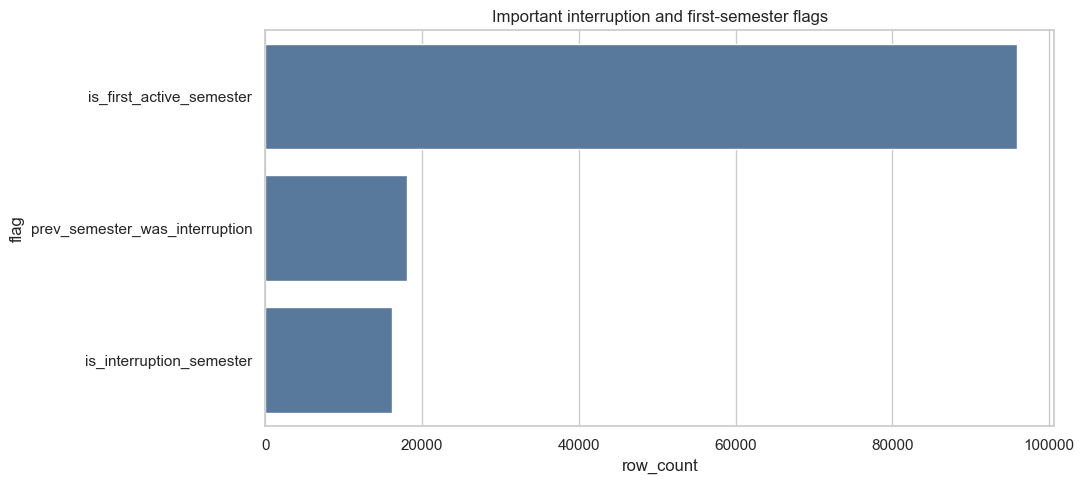

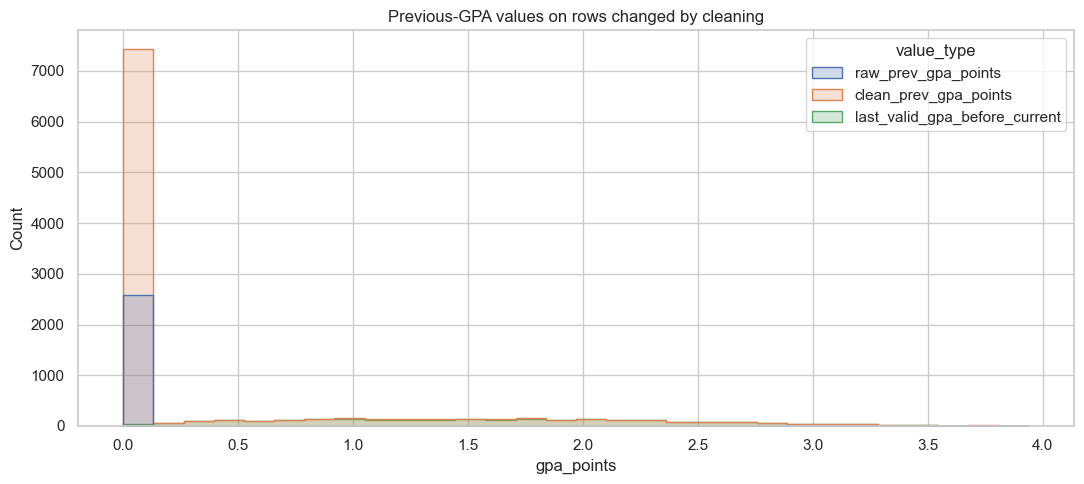

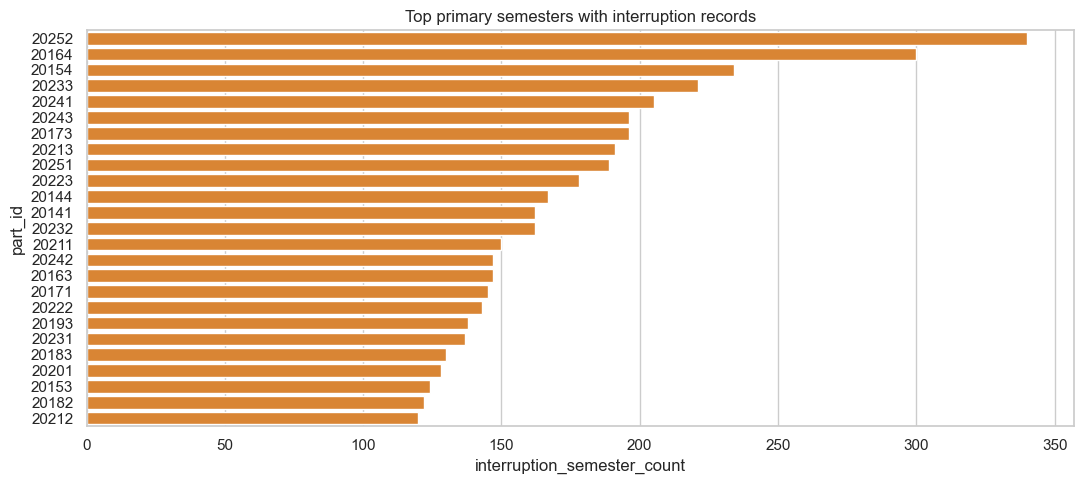

In [12]:
# Important change plots only: interruption semesters and previous-GPA fallback cleaning on df_primary.
important_flag_columns = [
    'is_interruption_semester',
    'prev_semester_was_interruption',
    'is_first_active_semester',
]
important_flag_columns = [col for col in important_flag_columns if col in df_model_a.columns]

important_flag_counts = pd.DataFrame({
    'flag': important_flag_columns,
    'row_count': [int(df_model_a[col].sum()) for col in important_flag_columns],
})

if not important_flag_counts.empty:
    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=important_flag_counts.sort_values('row_count', ascending=False),
        x='row_count',
        y='flag',
        color='#4C78A8',
    )
    plt.title('Important interruption and first-semester flags')
    plt.tight_layout()
    plt.show()

raw_prev_gpa = df_model_a['prev_gpa_points']
clean_prev_gpa = df_model_a['prev_gpa_points_clean']
changed_prev_gpa_mask = (
    raw_prev_gpa.isna()
    | raw_prev_gpa.ne(clean_prev_gpa).fillna(False)
)
changed_prev_gpa_plot = df_model_a.loc[changed_prev_gpa_mask].copy()

if changed_prev_gpa_plot.empty:
    print('No previous-GPA rows changed by the fallback rules.')
else:
    changed_prev_gpa_plot = changed_prev_gpa_plot.sample(
        n=min(len(changed_prev_gpa_plot), PLOT_SAMPLE_SIZE),
        random_state=42,
    )
    value_columns = [
        'prev_gpa_points',
        'prev_gpa_points_clean',
        'last_valid_gpa_before_current_semester',
    ]
    value_columns = [col for col in value_columns if col in changed_prev_gpa_plot.columns]
    gpa_plot_data = changed_prev_gpa_plot[value_columns].rename(columns={
        'prev_gpa_points': 'raw_prev_gpa_points',
        'prev_gpa_points_clean': 'clean_prev_gpa_points',
        'last_valid_gpa_before_current_semester': 'last_valid_gpa_before_current',
    }).melt(var_name='value_type', value_name='gpa_points')
    gpa_plot_data = gpa_plot_data.dropna(subset=['gpa_points'])

    if not gpa_plot_data.empty:
        plt.figure(figsize=(11, 5))
        sns.histplot(data=gpa_plot_data, x='gpa_points', hue='value_type', element='step', bins=30)
        plt.title('Previous-GPA values on rows changed by cleaning')
        plt.tight_layout()
        plt.show()

interruption_by_part = (
    semester_df.loc[semester_df['is_interruption_semester'] == 1]
    .groupby('part_id', dropna=False)
    .size()
    .reset_index(name='interruption_semester_count')
    .sort_values('interruption_semester_count', ascending=False)
    .head(25)
)

if interruption_by_part.empty:
    print('No interruption semesters detected in df_primary.')
else:
    interruption_by_part['part_id'] = interruption_by_part['part_id'].astype('string').fillna('missing')
    plt.figure(figsize=(11, 5))
    sns.barplot(data=interruption_by_part, x='interruption_semester_count', y='part_id', color='#F58518')
    plt.title('Top primary semesters with interruption records')
    plt.tight_layout()
    plt.show()


In [13]:
save_parquet(df_model_a, FINAL_DIR / "without_outliers.parquet", index=None)

WindowsPath('D:/AI/Real projects/Academic_Advisor/data/final/without_outliers.parquet')